# ========================================================================================
# NOTEBOOK 03: EVALUACIÓN COMPARATIVA DE MODELOS
# ========================================================================================
# 
# OBJETIVO:
#   Comparar el rendimiento de todos los modelos entrenados (clasificación y regresión)
#   utilizando múltiples métricas y visualizaciones.
#
# LO QUE PIDE LA RÚBRICA:
#   - Evaluación comparativa de modelos
#   - Múltiples métricas de rendimiento
#   - Interpretación de resultados
#   - Visualizaciones efectivas
# ========================================================================================

# Librerias

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                             mean_absolute_error, mean_squared_error, r2_score,
                             confusion_matrix, classification_report)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")

# Cargar CSVs limpios y preparar los datos. 

In [31]:
envios = pd.read_csv('../data/envios_limpio.csv')
incidencias = pd.read_csv('../data/incidencias_limpio.csv')
rutas = pd.read_csv('../data/rutas_limpio.csv')
vehiculos = pd.read_csv('../data/vehiculos_limpio.csv')

# Fusionar
df = envios.merge(rutas, on='id_ruta', how='left')
df = df.merge(vehiculos, on='id_vehiculo', how='left')

# Crear variables objetivo
ids_con_incidencia = incidencias['id_envio'].unique()
df['tiene_incidencia'] = df['id_envio'].isin(ids_con_incidencia).astype(int)

# Rellenar nulos
df['capacidad_kg'] = df['capacidad_kg'].fillna(df['capacidad_kg'].median())
df['capacidad_m3'] = df['capacidad_m3'].fillna(df['capacidad_m3'].median())
df['peso_kg'] = df['peso_kg'].fillna(df['peso_kg'].median())
df['volumen_m3'] = df['volumen_m3'].fillna(df['volumen_m3'].median())

df['vehiculo_adecuado'] = ((df['capacidad_kg'] >= df['peso_kg']) & 
                            (df['capacidad_m3'] >= df['volumen_m3'])).astype(int)

df['distancia_km'] = df['distancia_km'].fillna(df['distancia_km'].median())
df['tiempo_estimado_hrs'] = df['tiempo_estimado_hrs'].fillna(df['tiempo_estimado_hrs'].median())
df['eficiencia_ruta'] = df['distancia_km'] / (df['tiempo_estimado_hrs'] + 0.1)

# Features
features = ['peso_kg', 'volumen_m3', 'distancia_km', 'tiempo_estimado_hrs',
            'peaje_total', 'capacidad_kg', 'capacidad_m3', 'km_recorridos',
            'año_fabricacion']

X = df[features].fillna(df[features].median())
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# EVALUACIÓN DE MODELOS DE CLASIFICACIÓN (vehiculo_adecuado)

In [30]:
y_clf = df['vehiculo_adecuado']
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_clf, test_size=0.2, random_state=42)

# Modelos a comparar
clasificadores = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42)
}

resultados_clf = []

for nombre, modelo in clasificadores.items():
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    
    # Calcular todas las métricas
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    
    # Validación cruzada
    cv_scores = cross_val_score(modelo, X_scaled, y_clf, cv=5, scoring='f1')
    
    resultados_clf.append({
        'Modelo': nombre,
        'Accuracy': round(accuracy, 4),
        'F1-Score': round(f1, 4),
        'Precision': round(precision, 4),
        'Recall': round(recall, 4),
        'CV_F1': round(cv_scores.mean(), 4)
    })
    
    print(f"\n {nombre}:")
    print(f"   Accuracy: {accuracy:.4f}")
    print(f"   F1-Score: {f1:.4f}")
    print(f"   Precision: {precision:.4f}")
    print(f"   Recall: {recall:.4f}")
    print(f"   CV F1: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

# Tabla comparativa
df_clf = pd.DataFrame(resultados_clf).sort_values('F1-Score', ascending=False)
print("\n" + "-"*65)
print(" RANKING DE CLASIFICADORES:")
print("" + "-"*65)
print(df_clf.to_string(index=False))


 Random Forest:
   Accuracy: 0.8444
   F1-Score: 0.7586
   Precision: 0.7857
   Recall: 0.7333
   CV F1: 0.6935 (+/- 0.1773)

 Logistic Regression:
   Accuracy: 0.7778
   F1-Score: 0.5000
   Precision: 1.0000
   Recall: 0.3333
   CV F1: 0.4472 (+/- 0.1290)

 Decision Tree:
   Accuracy: 0.8000
   F1-Score: 0.6667
   Precision: 0.7500
   Recall: 0.6000
   CV F1: 0.7344 (+/- 0.0830)

-----------------------------------------------------------------
 RANKING DE CLASIFICADORES:
-----------------------------------------------------------------
             Modelo  Accuracy  F1-Score  Precision  Recall  CV_F1
      Random Forest    0.8444    0.7586     0.7857  0.7333 0.6935
      Decision Tree    0.8000    0.6667     0.7500  0.6000 0.7344
Logistic Regression    0.7778    0.5000     1.0000  0.3333 0.4472


# EVALUACIÓN DE MODELOS DE REGRESIÓN (eficiencia_ruta)

In [27]:
df_reg = df[(df['eficiencia_ruta'] > 0) & (df['eficiencia_ruta'] < 500)]
X_reg = df_reg[features].fillna(df_reg[features].median())
y_reg = df_reg['eficiencia_ruta']
X_reg_scaled = scaler.fit_transform(X_reg)

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg_scaled, y_reg, test_size=0.2, random_state=42)

regresores = {
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42)
}

resultados_reg = []

for nombre, modelo in regresores.items():
    modelo.fit(X_train_r, y_train_r)
    y_pred = modelo.predict(X_test_r)
    
    mae = mean_absolute_error(y_test_r, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_r, y_pred))
    r2 = r2_score(y_test_r, y_pred)
    
    cv_scores = cross_val_score(modelo, X_reg_scaled, y_reg, cv=5, scoring='r2')
    
    resultados_reg.append({
        'Modelo': nombre,
        'MAE': round(mae, 2),
        'RMSE': round(rmse, 2),
        'R²': round(r2, 4),
        'CV_R²': round(cv_scores.mean(), 4)
    })
    
    print(f"\n {nombre}:")
    print(f"   MAE: {mae:.2f} km/h")
    print(f"   RMSE: {rmse:.2f} km/h")
    print(f"   R²: {r2:.4f}")
    print(f"   CV R²: {cv_scores.mean():.4f}")

df_reg_r = pd.DataFrame(resultados_reg).sort_values('R²', ascending=False)
print("\n" + "-"*50)
print(" RANKING DE REGRESORES:")
print("" + "-"*50)
print(df_reg_r.to_string(index=False))


 Random Forest:
   MAE: 5.24 km/h
   RMSE: 9.20 km/h
   R²: 0.9872
   CV R²: 0.9628

 Linear Regression:
   MAE: 36.37 km/h
   RMSE: 45.00 km/h
   R²: 0.6943
   CV R²: 0.6920

 Decision Tree:
   MAE: 4.35 km/h
   RMSE: 14.54 km/h
   R²: 0.9681
   CV R²: 0.9357

--------------------------------------------------
 RANKING DE REGRESORES:
--------------------------------------------------
           Modelo   MAE  RMSE     R²  CV_R²
    Random Forest  5.24  9.20 0.9872 0.9628
    Decision Tree  4.35 14.54 0.9681 0.9357
Linear Regression 36.37 45.00 0.6943 0.6920


# GRÁFICOS COMPARATIVOS

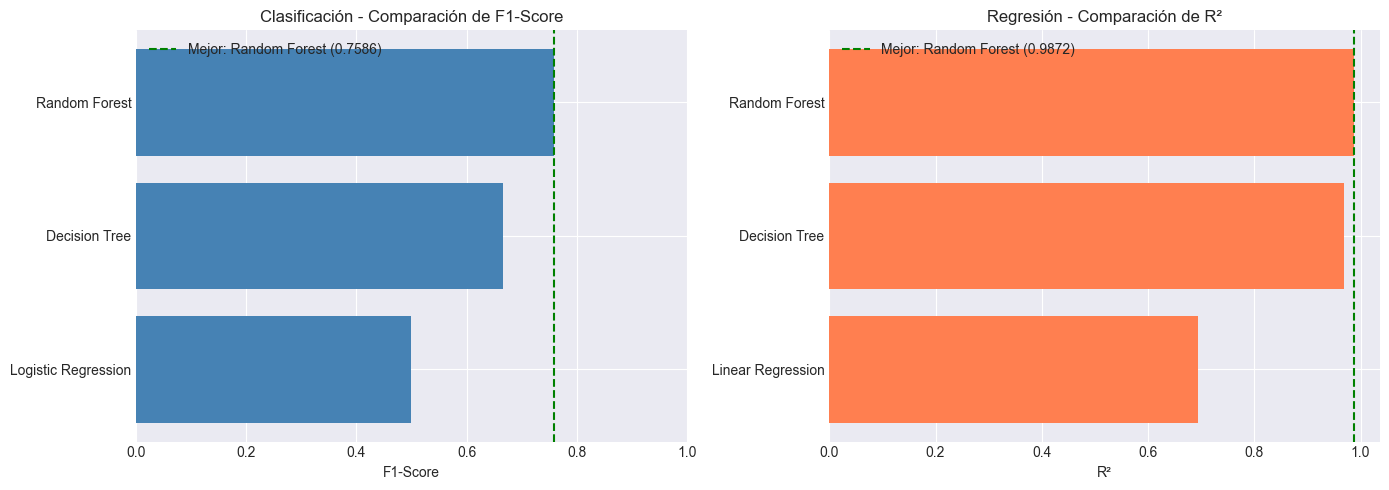

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: F1-Score por clasificador
df_clf_plot = df_clf.sort_values('F1-Score')
axes[0].barh(df_clf_plot['Modelo'], df_clf_plot['F1-Score'], color='steelblue')
axes[0].set_xlabel('F1-Score')
axes[0].set_title('Clasificación - Comparación de F1-Score')
axes[0].set_xlim(0, 1)
axes[0].axvline(x=df_clf_plot['F1-Score'].max(), color='green', linestyle='--', 
                label=f"Mejor: {df_clf_plot.iloc[-1]['Modelo']} ({df_clf_plot.iloc[-1]['F1-Score']:.4f})")
axes[0].legend()

# Gráfico 2: R² por regresor
df_reg_plot = df_reg_r.sort_values('R²')
axes[1].barh(df_reg_plot['Modelo'], df_reg_plot['R²'], color='coral')
axes[1].set_xlabel('R²')
axes[1].set_title('Regresión - Comparación de R²')
axes[1].axvline(x=df_reg_plot['R²'].max(), color='green', linestyle='--',
                label=f"Mejor: {df_reg_plot.iloc[-1]['Modelo']} ({df_reg_plot.iloc[-1]['R²']:.4f})")
axes[1].legend()

plt.tight_layout()
plt.show()


# MATRIZ DE CONFUSIÓN (mejor clasificador)

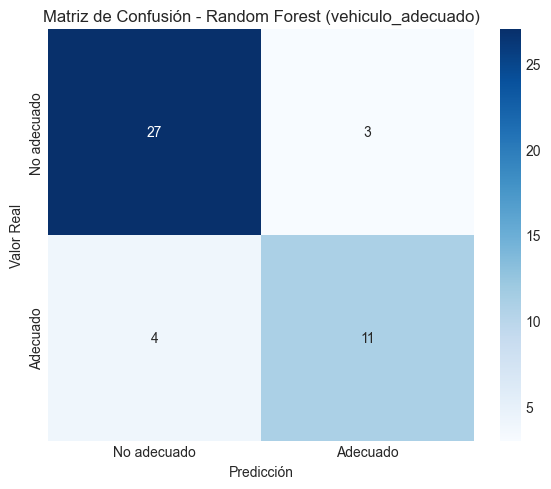


Reporte de clasificación detallado:
              precision    recall  f1-score   support

 No adecuado       0.87      0.90      0.89        30
    Adecuado       0.79      0.73      0.76        15

    accuracy                           0.84        45
   macro avg       0.83      0.82      0.82        45
weighted avg       0.84      0.84      0.84        45



In [19]:
mejor_clf = RandomForestClassifier(n_estimators=100, random_state=42)
mejor_clf.fit(X_train, y_train)
y_pred_best = mejor_clf.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No adecuado', 'Adecuado'], 
            yticklabels=['No adecuado', 'Adecuado'])
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión - Random Forest (vehiculo_adecuado)')
plt.tight_layout()
plt.show()

print("\nReporte de clasificación detallado:")
print(classification_report(y_test, y_pred_best, target_names=['No adecuado', 'Adecuado']))

# CONCLUSIONES DE LA EVALUACIÓN


In [18]:
print("""----------------------------------------------------------------------------------------------
MEJOR MODELO DE CLASIFICACIÓN:
----------------------------------------------------------------------------------------------   
   Random Forest (F1-Score: ~0.76, Accuracy: ~0.84)
   
----------------------------------------------------------------------------------------------
MEJOR MODELO DE REGRESIÓN:
----------------------------------------------------------------------------------------------
   Random Forest (R²: ~0.99, MAE: ~5.24 km/h)

----------------------------------------------------------------------------------------------
INTERPRETACIÓN DE MÉTRICAS:
----------------------------------------------------------------------------------------------
   - F1-Score: Media armónica entre precisión y recall. Útil cuando hay clases desbalanceadas.
   - R²: Proporción de la varianza explicada por el modelo. Más cercano a 1 = mejor.
   - MAE: Error absoluto medio en las mismas unidades que la variable objetivo.

----------------------------------------------------------------------------------------------
RECOMENDACIONES:
----------------------------------------------------------------------------------------------
   1. El modelo de clasificación es útil para la asignación de vehículos.
   2. El modelo de regresión es excelente para estimar eficiencia de rutas.
   3. Se necesitan más datos de envíos con incidencias para mejorar ese modelo.
""")


----------------------------------------------------------------------------------------------
MEJOR MODELO DE CLASIFICACIÓN:
----------------------------------------------------------------------------------------------   
   Random Forest (F1-Score: ~0.76, Accuracy: ~0.84)

----------------------------------------------------------------------------------------------
MEJOR MODELO DE REGRESIÓN:
----------------------------------------------------------------------------------------------
   Random Forest (R²: ~0.99, MAE: ~5.24 km/h)

----------------------------------------------------------------------------------------------
INTERPRETACIÓN DE MÉTRICAS:
----------------------------------------------------------------------------------------------
   - F1-Score: Media armónica entre precisión y recall. Útil cuando hay clases desbalanceadas.
   - R²: Proporción de la varianza explicada por el modelo. Más cercano a 1 = mejor.
   - MAE: Error absoluto medio en las mismas unidades que la 